In [ ]:
%pip install be-great pandas sdv scikit-learn

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# Definimos el modelo (DistilGPT-2 es ligero y excelente para tablas)
model_name = "tabularisai/Qwen3-0.3B-distil"
save_path = "./modelo_transformer_local"

print(f"Descargando {model_name}...")

# Descargamos Tokenizer y Modelo
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# Guardamos en local
tokenizer.save_pretrained(save_path)
model.save_pretrained(save_path)

print(f"¡Listo! Copia la carpeta '{save_path}' a tu máquina sin internet.")

/home/aperez/workspace/synthetic_data/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Descargando tabularisai/Qwen3-0.3B-distil...


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.31s/it]

¡Listo! Copia la carpeta './modelo_transformer_local' a tu máquina sin internet.


In [4]:
import pandas as pd
from be_great import GReaT
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality

# 1. Cargar el dataset adjunto
df_real = pd.read_csv('bank-full.csv', sep=';')

# Para la PoC, tomamos una muestra representativa para optimizar tiempos de GPU/CPU
# En producción (Vertex AI), usaríamos el dataset completo.
df_train = df_real.sample(n=1000, random_state=42) 

print(f"Dataset cargado: {df_real.shape[0]} registros.")
print("Columnas detectadas:", df_real.columns.tolist())

Dataset cargado: 45211 registros.
Columnas detectadas: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [5]:
import pandas as pd
from be_great import GReaT

# 1. Ruta donde copiaste la carpeta
local_model_path = "./modelo_transformer_local"

# 2. Cargamos el dataset local (ejemplo)
df = pd.read_csv("bank-full.csv")

# 3. Inicializamos GReaT apuntando a la ruta local
# Importante: llm=local_model_path evita que intente conectar a internet
model = GReaT(
    llm=local_model_path,  
    float_precision=3,  # Limit floating-point precision to 3 decimal places
    batch_size=64,       # Use smaller batch size for small datasets
    epochs=100,         # Train for more epochs with small data
    bf16=True           # Enable half-precision training for faster computation and lower memory usage
)

# Entrenamiento
model.fit(df_train)
model.save("Qwen3-0.3B-distil.pickle")



Loading weights: 100%|██████████| 156/156 [00:00<00:00, 3474.30it/s]
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss


OutOfMemoryError: CUDA out of memory. Tried to allocate 3.70 GiB. GPU 0 has a total capacity of 7.96 GiB of which 0 bytes is free. Including non-PyTorch memory, this process has 17179869184.00 GiB memory in use. Of the allocated memory 16.08 GiB is allocated by PyTorch, and 4.11 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# 3. Generación de datos sintéticos
# Vamos a generar 500 registros nuevos "soñados" por el modelo
df_synthetic = model.sample(n_samples=500, guided_sampling=True)

# Limpieza rápida: GREAT a veces genera strings con espacios extra
df_synthetic = df_synthetic.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

print("Muestra de datos sintéticos generados:")
display(df_synthetic.head())

100%|██████████| 500/500 [10:36<00:00,  1.27s/it]

Muestra de datos sintéticos generados:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,17.0,management,single,secondary,no,-1.0,no,no,unknown,13.0,"-1, housing is no, housing is no, campaign is ...",-1.0,1.0,13.0,0.0,unknown,no
1,53.0,management,married,no and contact is no,no,-1.0,no.,no,cellular,-1.0,June,4961.0,2.0,-1.0,0.0,unknown,-1
2,54.0,management,married,secondary,no,3873.0,no,no,not authorized,-1.0,-1,21.0,1.0,-1.0,0.0,unknown,a job
3,54.0,management,"single, duration is 59",secondary,no,-1.0,no,no,cellular,13.0,no,491.0,6.0,-1.0,0.0,unknown,no
4,36.0,management,married,"secondary, campaign is 1",no,2287470.0,no,no,unknown,-1.0,unknown,1.0,4.0,-1.0,0.0,unknown,secondary


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 17/17 [00:00<00:00, 1149.14it/s]|
Column Shapes Score: 64.0%

(2/2) Evaluating Column Pair Trends: |██████████| 136/136 [00:00<00:00, 455.93it/s]|
Column Pair Trends Score: 41.55%

Overall Score (Average): 52.77%


--- Reporte de Calidad de Datos Sintéticos ---
Puntaje General: 52.77%


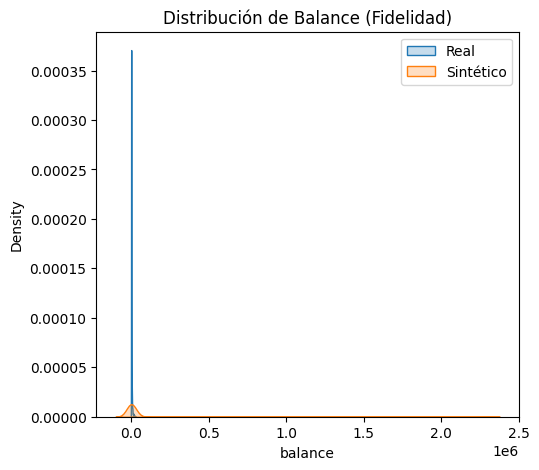

In [ ]:
# Crear metadatos automáticamente a partir del dataframe real
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_real)

# Ejecutar evaluación de fidelidad
quality_report = evaluate_quality(
    real_data=df_train,
    synthetic_data=df_synthetic,
    metadata=metadata
)

# Visualizar resultados por columna
print("\n--- Reporte de Calidad de Datos Sintéticos ---")
print(f"Puntaje General: {quality_report.get_score():.2%}")

# Comparar una correlación clave: Age vs Balance
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.kdeplot(df_train['balance'], label='Real', fill=True)
sns.kdeplot(df_synthetic['balance'], label='Sintético', fill=True)
plt.title('Distribución de Balance (Fidelidad)')
plt.legend()



In [ ]:
from sdv.evaluation.single_table import evaluate_quality

# Evaluación de calidad comparando Original vs Sintético
quality_report = evaluate_quality(
    real_data=df_train,
    synthetic_data=df_synthetic,
    metadata={
        "columns": {
            "edad": {"sdv_type": "numerical"},
            "balance": {"sdv_type": "numerical"},
            "score_crediticio": {"sdv_type": "numerical"},
            "es_fraudulento": {"sdv_type": "categorical"}
        }
    }
)

print(f"Puntaje de Calidad Total: {quality_report.get_score():.2%}")

TypeError: evaluate_quality() missing 1 required positional argument: 'metadata'

In [ ]:
import torch
import gc

# 1. Eliminar el objeto del modelo (y cualquier otro pesado)
if 'model' in locals():
    del model
if 'df_synthetic' in locals():
    del df_synthetic

# 2. Forzar la recolección de basura de Python
gc.collect()

# 3. Vaciar el caché de PyTorch (esto libera la VRAM físicamente)
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    
print("Memoria de GPU liberada.")

Memoria de GPU liberada.
